# Overview of the mini dataset

## Motivation
The performance of a machine learning model is highly dependent on the quality of the dataset used for training. The quality of the dataset can be affected by several factors such as the number of images or the distribution of the classes.  Therefore, it is important to have a good understanding of the dataset before training the model. To simplify a quick exploration of the data, we created a `overview` module. The overview module iterates over all the images found in the given dataset and extracts the needed information of the image or image path. The extracted information are then summarized in a single dataframe.

## Requirements
For this notebook to run, you need have followed the instructions in the `README.md` file within the setup section to install the required packages and setup the dataset. The different paths of the code cell bellow should exist for a successful run of the notebook.

In [1]:

from pathlib import Path

# paths used in the notebook, 
# if you want to run the notebook on other data, please change the paths accordingly.
base_path = Path("..")
dataset_path = base_path / "data" / "mini_dataset"

# path to example images
img_path = dataset_path / "aphanizomenon" / "SPC-EAWAG-0P5X-1570543372901157-3725350526242-001629-055-1224-2176-84-64.jpeg"
img_path_2 = dataset_path / "aphanizomenon" / "SPC-EAWAG-0P5X-1570543374882008-3725352526408-001649-138-1826-1500-72-56.jpeg"

print(f"Dataset path exists: {dataset_path.exists()}")
print(f"First image path exists: {img_path.exists()}")
print(f"Second image path exists: {img_path_2.exists()}") 

Dataset path exists: True
First image path exists: True
Second image path exists: True



# Exploring a single image
Start small by exploring a single image. 

## Loading the image

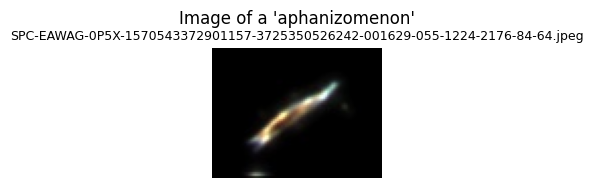

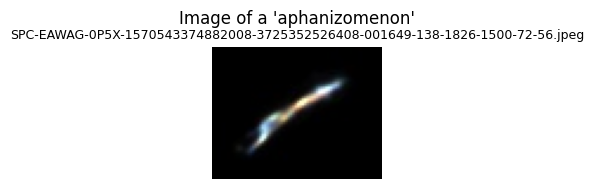

In [2]:
from PIL import Image
import matplotlib.pyplot as plt

def show_image(img_path):
    plt.figure(figsize=(2, 2))
    img = plt.imread(img_path)
    plt.imshow(img)
    plt.axis('off')
    plt.suptitle(f"Image of a '{img_path.parent.name}'", fontsize=12)
    plt.title(img_path.name, fontsize=9)
    plt.tight_layout()
    plt.subplots_adjust(top=0.85)
    plt.show()

show_image(img_path)
show_image(img_path_2)

## Generating an overview of the mini dataset

The dictionary below contains the paths to the different versions of the dataset. The paths are used to generate the overview of the dataset and the tag for identifing the version of the dataset for further analysis. Equals the functionality of the configuration "config/dataset_versions.json". 

In [3]:
# define the paths to the data folders of the actual ZooLake versions
zoolake_version_path = {"mini": dataset_path}


The generated overview of the dataset will be stored in a dataframe. The dataframe contains the following columns:

- `image`: The name of the image file
- `hash`: The hash value of the image
- `class`: The class of the image, extracted from the parent folder of the image
- `timestamp`: The timestamp of the image, extracted from the filename of the image (SPC specific)
- `version_*`: Column containing a bool if the image is part of the given version of the dataset

In [4]:
from lit_ecology_classifier.data_overview.overview_creator import OverviewCreator

overview_creator = OverviewCreator(zoolake_version_path)
overview_df = overview_creator.get_overview_df()
overview_df.head()

,image,class,sha256,date,version_mini
0,SPC-EAWAG-0P5X-1657469153953175-61976020245260...,keratella_quadrata,2bf0ee058f81569527f44b2902f99eebfff315ef04b66f...,2022-07-10 16:05:53+00:00,True
1,SPC-EAWAG-0P5X-1529971633256303-1685616084007-...,keratella_quadrata,b51329bb043ea0cbf4e645dbd8b3e2b671212894b0a979...,2018-06-26 00:07:13+00:00,True
2,SPC-EAWAG-0P5X-1534593947131228-276543382109-0...,keratella_quadrata,370040c99ac335db709635be9d49dc2d9e95b314fab6d4...,2018-08-18 12:05:47+00:00,True
3,SPC-EAWAG-0P5X-1530061231883348-1775213498675-...,keratella_quadrata,358e800d0f731d9bade3bc958cbb04822b2a97af9b7a69...,2018-06-27 01:00:31+00:00,True
4,SPC-EAWAG-0P5X-1657375349510541-61882217063707...,keratella_quadrata,9b925a9ab1aa0e77493fb77ac73c35fe1358fbaab5ceef...,2022-07-09 14:02:29+00:00,True


## Exploring the mini dataset

In [5]:
# Check that not two images are duplicate
duplicate_df = overview_creator.get_duplicates_df()

INFO:root:No duplicates found in the dataset


No duplicates found in the dataset


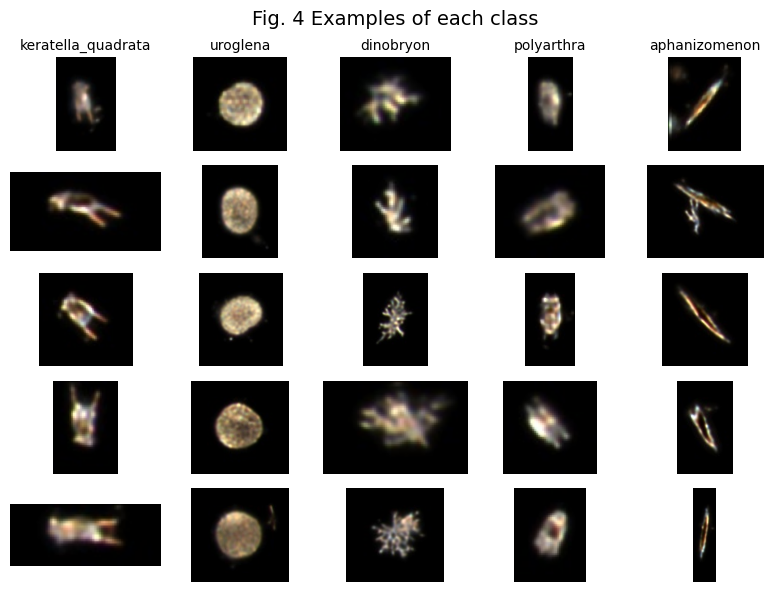

In [6]:
import matplotlib.pyplot as plt
import os
import pandas as pd

def image_examples():
    overview_df["image_path"] = overview_df.apply(lambda x: os.path.join(dataset_path, x["class"], x["image"]), axis=1)
    images_per_class = 5
    classes = overview_df["class"].unique()

    # Erstellen einer Figure mit Subplots
    fig, axes = plt.subplots(images_per_class, len(classes), figsize=(8,6))

    for j, label in enumerate(classes):
        class_images = overview_df[overview_df["class"] == label]["image_path"].head(len(classes))
        
        for i, img_path in enumerate(class_images):
            ax = axes[i, j] 
            img = plt.imread(img_path)
            ax.imshow(img)
            ax.axis("off")
            if i == 0:
                ax.set_title(label, fontsize=10)

    plt.tight_layout()
    plt.suptitle("Fig. 4 Examples of each class", fontsize=14)
    plt.subplots_adjust(top=0.9)
    plt.show()

image_examples()

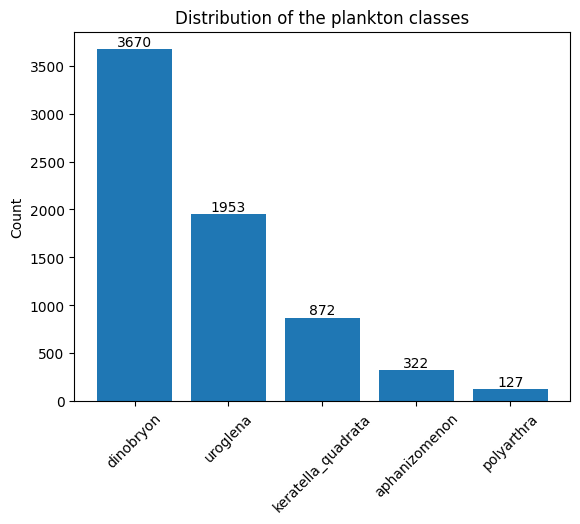

In [7]:
def plot_distributions_of_plankton_classes(df):
    counts_class= df['class'].value_counts()
    order_by_count = list(counts_class.index)
    df['class'] = pd.Categorical(df['class'], order_by_count)
    df = df.sort_values(by='class')
    plt.bar(counts_class.index, counts_class.values)

    # add the count of each class to the bar
    for i, count in enumerate(counts_class.values):
        plt.text(i, count, count, ha='center', va='bottom')
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.title("Distribution of the plankton classes")
    plt.show()


plot_distributions_of_plankton_classes(overview_df)


In [8]:
artifacts_path = dataset_path / '..' / "mini_dataset_artifact"
overview_path = artifacts_path / "overview.csv"

if not artifacts_path.exists():
    artifacts_path.mkdir(parents=True)

overview_creator.save_overview_df(overview_path)

INFO:root:Saved overview to ../data/mini_dataset/../mini_dataset_artifact/overview.csv


# Creation of splits
We now present how the splits for the models and the dataset version are handled inside the plankton classifier pipeline.

## Motivation
The split overview was created with the ambition of keeping informations and track of the used split and allow a simple and understandable reproduction. This makes things simpler, when multiple people work over time independently work on the same project.

The split overview contains: 
$$
\small
\begin{array}{c}
\textbf{Description of the split overview dataframe}\\
\newline
\begin{array}{|l|l|}
\hline
\textbf{Column name} & \textbf{Description} \\
\hline
\text{Dataset version} & \text{Version of the Dataset used for the split} \\
\text{Split strategy} & \text{Used split strategy} \\ 
\text{Filter strategy} & \text{Used filtersplit strategy} \\
\text{Combined split hash} & \text{Hash value to identfiy the split} \\
\text{Description} & \text{Place to add a short description of the split} \\
\text{Args*} & \text{Arguments used inside the filter and split strategy are also saved}\\
\hline
\end{array}
\end{array}
$$

## Creation of a simple split

The simplest way to create a split is to use the build in split strategies based on the `sklearn` library. The built in split strategies are:

- `Stratified`: Creates a stratified split based on the "class" column of the given dataset overview.
- `Random`: Creates a random split based on the given dataset overview.

and the filter strategies:

- `PlanktonFilter`: This filters unwanted images. Can be ignored for the purpose of this exercise.


### Split with random strategy

In [9]:
from lit_ecology_classifier.splitting.split_processor import SplitProcessor

split_args = {"train_size": 0.8}

random_split_processor = SplitProcessor(
                                artefacts_folder= artifacts_path,
                                image_overview= overview_df,
                                split_strategy= "Random",
                                filter_strategy= "PlanktonFilter",
                                split_args= split_args
                                )

random_split_df = random_split_processor.get_split_df()
random_split_df.head()

INFO:lit_ecology_classifier.splitting.split_processor:Existing split found, reloading split.
INFO:lit_ecology_classifier.splitting.split_processor:Reloading split based on hash value: 4d1860aa6bfc3ab6f32cb7a4bdc8cc9b0092213b3b0c9c0fb11eebe304cf69d5
INFO:lit_ecology_classifier.splitting.split_processor:Path to used split: ../data/mini_dataset/../mini_dataset_artifact/splits/4d1860aa6bfc3ab6f32cb7a4.csv
INFO:lit_ecology_classifier.splitting.split_processor:Split reloaded successfully.


,image,class,sha256,date,version_mini,image_path,class_map,split
0,SPC-EAWAG-0P5X-1657469153953175-61976020245260...,keratella_quadrata,2bf0ee058f81569527f44b2902f99eebfff315ef04b66f...,2022-07-10 16:05:53+00:00,True,../data/mini_dataset/keratella_quadrata/SPC-EA...,2,test
1,SPC-EAWAG-0P5X-1529971633256303-1685616084007-...,keratella_quadrata,b51329bb043ea0cbf4e645dbd8b3e2b671212894b0a979...,2018-06-26 00:07:13+00:00,True,../data/mini_dataset/keratella_quadrata/SPC-EA...,2,train
2,SPC-EAWAG-0P5X-1534593947131228-276543382109-0...,keratella_quadrata,370040c99ac335db709635be9d49dc2d9e95b314fab6d4...,2018-08-18 12:05:47+00:00,True,../data/mini_dataset/keratella_quadrata/SPC-EA...,2,train
3,SPC-EAWAG-0P5X-1530061231883348-1775213498675-...,keratella_quadrata,358e800d0f731d9bade3bc958cbb04822b2a97af9b7a69...,2018-06-27 01:00:31+00:00,True,../data/mini_dataset/keratella_quadrata/SPC-EA...,2,test
4,SPC-EAWAG-0P5X-1657375349510541-61882217063707...,keratella_quadrata,9b925a9ab1aa0e77493fb77ac73c35fe1358fbaab5ceef...,2022-07-09 14:02:29+00:00,True,../data/mini_dataset/keratella_quadrata/SPC-EA...,2,train


In [10]:
random_class_map = random_split_processor.get_class_map()
random_split_processor.get_class_map()
random_class_map

{'keratella_quadrata': 2,
 'uroglena': 4,
 'dinobryon': 1,
 'polyarthra': 3,
 'aphanizomenon': 0}

In [11]:
random_split_entry = random_split_processor.get_new_split_entry()
random_split_entry.head()

Reloadedf split, returning the reloaded split entry


,split_strategy,filter_strategy,combined_split_hash,description,priority_classes,rest_classes,split_train_size
0,Random,PlanktonFilter,4d1860aa6bfc3ab6f32cb7a4bdc8cc9b0092213b3b0c9c...,Random split of the mini dataset,,,0.8


In [12]:
random_split_processor.save_split("Random split of the mini dataset")

INFO:lit_ecology_classifier.splitting.split_processor:Reloaded split, no need to save the split again.


In [13]:
random_split_hash = random_split_entry['combined_split_hash'].iloc[0]

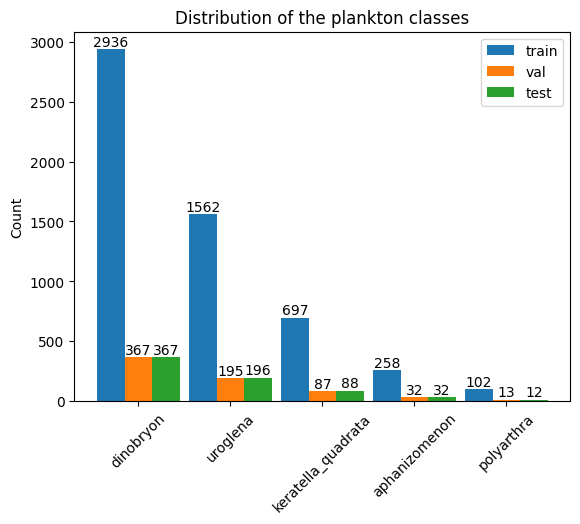

In [14]:
import numpy as np
from matplotlib import pyplot as plt

def plot_distributions_of_plankton_classes_by_split(df, splits=None):


    if splits is None:
        splits=['train','val','test']

    width = .9/len(splits)
    
    for isplit,split in enumerate(splits):
        
        counts_class= df[df['split']==split]['class'].value_counts() 
        order_by_count = list(counts_class.index)
        df['class'] = pd.Categorical(df['class'], order_by_count)
        df = df.sort_values(by='class')
        
        # plt.bar(counts_class.index, counts_class.values, width)
        plt.bar(np.arange(len(counts_class.values))+isplit*width, counts_class.values, width, label=split)
    
        # add the count of each class to the bar
        for i, count in enumerate(counts_class.values):
            plt.text(i+width*isplit, count, count, ha='center', va='bottom')
    plt.ylabel("Count")
    
    plt.xticks(np.arange(len(counts_class.values))+width, counts_class.index,rotation=45)
    plt.legend()
    plt.title("Distribution of the plankton classes")
    plt.show()

plot_distributions_of_plankton_classes_by_split(random_split_df)

### Split with stratified strategy

INFO:lit_ecology_classifier.splitting.split_processor:Existing split found, reloading split.
INFO:lit_ecology_classifier.splitting.split_processor:Reloading split based on hash value: 4d1860aa6bfc3ab6f32cb7a4bdc8cc9b0092213b3b0c9c0fb11eebe304cf69d5
INFO:lit_ecology_classifier.splitting.split_processor:Path to used split: ../data/mini_dataset/../mini_dataset_artifact/splits/4d1860aa6bfc3ab6f32cb7a4.csv
INFO:lit_ecology_classifier.splitting.split_processor:Split reloaded successfully.
INFO:lit_ecology_classifier.splitting.split_processor:Reloaded split, no need to save the split again.


Reloadedf split, returning the reloaded split entry


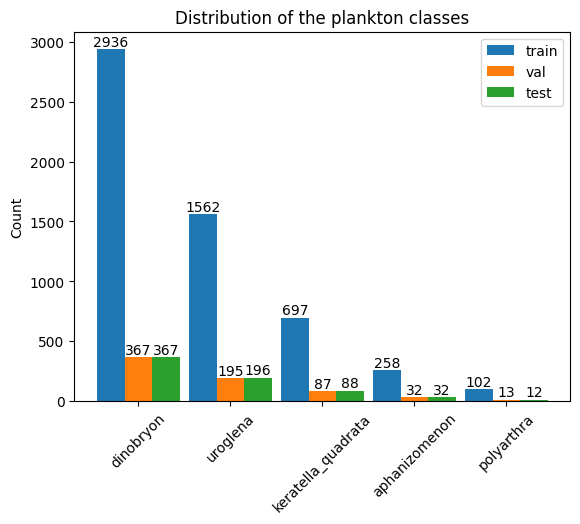

In [15]:
strat_split_processor = SplitProcessor(
                                artefacts_folder= artifacts_path,
                                image_overview= overview_df,
                                split_strategy= "Stratified",
                                filter_strategy= "PlanktonFilter",
                                split_args= split_args
                                )

strat_split_df = strat_split_processor.get_split_df()
strat_split_df.head()
strat_class_map=strat_split_processor.get_class_map()
strat_split_entry = strat_split_processor.get_new_split_entry()
strat_split_processor.save_split("Random split of the mini dataset")
strat_split_hash = strat_split_entry['combined_split_hash'].iloc[0]


plot_distributions_of_plankton_classes_by_split(strat_split_df)

## Undersampling

Make an undersampled training set where all the class counts are set to that of the minority class

In [16]:
def undersample(df):
    '''
    Undersamples training set, putting all counts to the minimum count
    '''
    min_counts=min(df[df['split']=='train']['class'].value_counts())
    all_indices=list(df.index)
    indices_keep=[]
    indices_remove=[]
    for my_class in df['class'].unique():
        class_indices_keep   =  df[(df['split']=='train') & (df['class']==my_class)].index[:min_counts].to_list()
        indices_keep.append(class_indices_keep)

    indices_keep=np.ndarray.flatten(np.array(indices_keep))

    
    return pd.concat([df.iloc[indices_keep],df[df['split']=='val'],df[df['split']=='test']])

df_undersampled=undersample(strat_split_df)


Class counts

In [17]:
print('Original dataset')
print('Training set')
print(strat_split_df[strat_split_df['split']=='train']['class'].value_counts())
print('Validation set')
print(strat_split_df[strat_split_df['split']=='val']['class'].value_counts())
print('Test set')
print(strat_split_df[strat_split_df['split']=='test']['class'].value_counts())

Original dataset
Training set
class
dinobryon             2936
uroglena              1562
keratella_quadrata     697
aphanizomenon          258
polyarthra             102
Name: count, dtype: int64
Validation set
class
dinobryon             367
uroglena              195
keratella_quadrata     87
aphanizomenon          32
polyarthra             13
Name: count, dtype: int64
Test set
class
dinobryon             367
uroglena              196
keratella_quadrata     88
aphanizomenon          32
polyarthra             12
Name: count, dtype: int64


Undersampled class counts

In [18]:
print('Undersampled dataset')
print('Training set')
print(df_undersampled[df_undersampled['split']=='train']['class'].value_counts())
print('Validation set')
print(df_undersampled[df_undersampled['split']=='val']['class'].value_counts())
print('Test set')
print(df_undersampled[df_undersampled['split']=='test']['class'].value_counts())

Undersampled dataset
Training set
class
dinobryon             102
uroglena              102
keratella_quadrata    102
aphanizomenon         102
polyarthra            102
Name: count, dtype: int64
Validation set
class
dinobryon             367
uroglena              195
keratella_quadrata     87
aphanizomenon          32
polyarthra             13
Name: count, dtype: int64
Test set
class
dinobryon             367
uroglena              196
keratella_quadrata     88
aphanizomenon          32
polyarthra             12
Name: count, dtype: int64


## Oversampling

Make an undersampled training set where all the class counts are set to that of the minority class

In [19]:
def approximate_oversampling(df):
    '''
    Oversamples training set, by multiplying all the images of the minority class an integer number of times 
    (so the ratio between majority and minority is now <2)
    '''
    max_counts=max(df[df['split']=='train']['class'].value_counts())
    indices=[]
    for my_class in df['class'].unique():
        class_counts=df[(df['split']=='train') & (df['class']==my_class)]['class'].value_counts().values[0]
        factor=int(max_counts/class_counts)
        df_to_replicate=df[(df['class']==my_class) & (df['split']=='train')]
        for i in range(factor-1):
            df=pd.concat([df,df_to_replicate],ignore_index=True)
    
    return df

df_oversampled=approximate_oversampling(strat_split_df)

In [20]:
print('Oversampled dataset')
print('Training set')
print(df_oversampled[df_oversampled['split']=='train']['class'].value_counts())
print('Validation set')
print(df_oversampled[df_oversampled['split']=='val']['class'].value_counts())
print('Test set')
print(df_oversampled[df_oversampled['split']=='test']['class'].value_counts())

Oversampled dataset
Training set
class
dinobryon             2936
polyarthra            2856
aphanizomenon         2838
keratella_quadrata    2788
uroglena              1562
Name: count, dtype: int64
Validation set
class
dinobryon             367
uroglena              195
keratella_quadrata     87
aphanizomenon          32
polyarthra             13
Name: count, dtype: int64
Test set
class
dinobryon             367
uroglena              196
keratella_quadrata     88
aphanizomenon          32
polyarthra             12
Name: count, dtype: int64


# Image Transformations


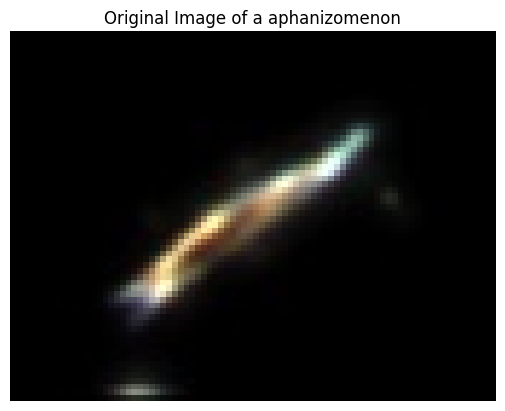

In [21]:
# prepare the image 
file_path = dataset_path / "aphanizomenon" / "SPC-EAWAG-0P5X-1570543372901157-3725350526242-001629-055-1224-2176-84-64.jpeg"

image = Image.open(file_path)

#show the original image
plt.imshow(image)
plt.title("Original Image of a aphanizomenon")
plt.axis('off')
plt.show()

In [22]:
import lit_ecology_classifier.data.image_transformation as it
target_size = (128, 128)

# set train flag to false to just resize the image and transform it to a tensor
pipeline_with_proportions = it.define_transformation_pipeline(target_size = target_size, resize_with_proportions=True, train=False)
pipeline_without_proportions = it.define_transformation_pipeline(target_size = target_size, resize_with_proportions=False, train=False)

tensor_with_proportions = pipeline_with_proportions(image)
tensor_without_proportions = pipeline_without_proportions(image)



size (128, 128)
size (128, 128)


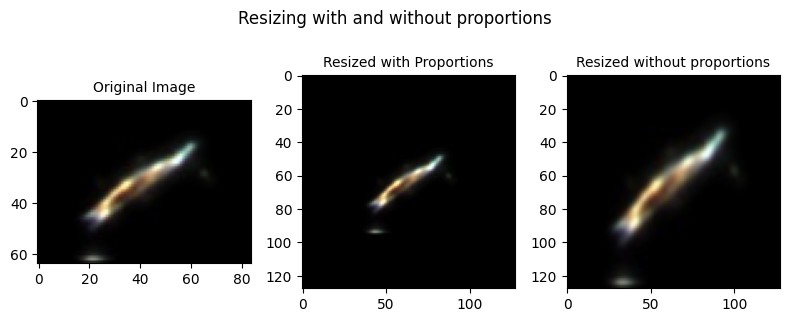

In [23]:

#show the different images
fig, ax = plt.subplots(1, 3, figsize=(8, 5))

ax[0].imshow(image)
ax[0].set_title("Original Image", fontsize = 10)

# change the tensor to numpy array and change the order of the channels
ax[1].imshow(tensor_with_proportions.permute(1, 2, 0))
ax[1].set_title("Resized with Proportions", fontsize = 10)


ax[2].imshow(tensor_without_proportions.permute(1, 2, 0))
ax[2].set_title("Resized without proportions", fontsize = 10)
plt.suptitle("Resizing with and without proportions", fontsize = 12)


plt.subplots_adjust(right=1.5,top=0.8)
plt.tight_layout(rect=[0, 0.03, 1, 1.3])

plt.savefig('resize-rescale.png')
plt.show()


# Augmentations

size (128, 128)
size (128, 128)
size (128, 128)
size (128, 128)


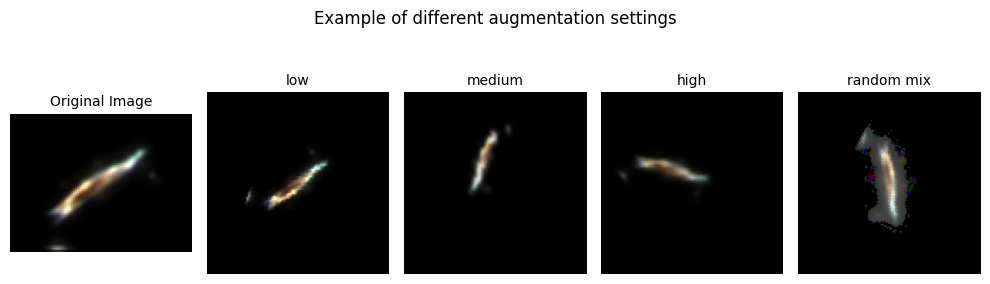

In [24]:
import torch
image = Image.open(file_path)

torch.manual_seed(1)
# aug_levels
augmentation_levels = ["low", "medium", "high", "random_mix"]


# create a map function to create the different transformations to include the augmentation level and resize with proportions flag
def create_pipelines(augmentation_level, resize_with_proportions, image):
    pipeline = it.define_transformation_pipeline(target_size = target_size, resize_with_proportions=resize_with_proportions, train=True, augmentation_level=augmentation_level)
    return pipeline(image)

# create a dictionary with all the transformations
all_augs = {augmentation_level: create_pipelines(augmentation_level, True, image) for augmentation_level in augmentation_levels}


fig, ax = plt.subplots(1, 5, figsize=(10, 5))  

# plot the original image
ax[0].imshow(image)
ax[0].set_title("Original Image", fontsize = 10)
ax[0].axis('off')

for i, (transformation_name, image) in enumerate(all_augs.items(), 1):
    image = image.permute(1, 2, 0)

    ax[i].imshow(image)
    ax[i].set_title(f"{transformation_name.replace('_', ' ')}", fontsize=10)
    ax[i].axis('off')
     
plt.suptitle("Example of different augmentation settings", fontsize = 12)
plt.tight_layout(rect=[0, 0.03, 1, 1.3])

plt.show()


# Training


THe model training is based on the [Pytorch Lightning](https://pytorch-lightning.readthedocs.io/en/latest/) framework. It is a high-level interface for Pytorch that makes it easier to train models on multiple GPUs or Clusters.

### LightningDataModule and DataLoaders

Native pytorch dataloaders are used to load the images and labels for the training. The LightningDataModule orchestrates the correct loading of the data and the creation of the dataloaders for training and validation on multiple GPUs.


In [25]:
from lit_ecology_classifier.data.datamodule import DataModule
import logging
from lightning.pytorch.loggers import CSVLogger

train_out = base_path / "train_out"
logger = CSVLogger(save_dir= train_out, name='csv_logs')

batch_size=32
max_epochs = 2
my_split=df_oversampled

datamodule = DataModule(
        datapath= dataset_path,   # path to the dataset
        dataset = "mini_example", # name of the dataset, needed for the wandb logging
        batch_size= batch_size,   # number of images per batch
        splits= my_split,         # split of the data
        augmentation_level = "low", # augmentation level
        resize_with_proportions = True,
        target_size = 224,
)

datamodule.setup()

INFO:root: Extracting class map from tar file.
INFO:lit_ecology_classifier.helpers.helpers:Extracting class map.
INFO:lit_ecology_classifier.helpers.helpers:Detected directory.
INFO:lit_ecology_classifier.helpers.helpers:Found 5 classes.
INFO:root:Class map: {'aphanizomenon': 0, 'dinobryon': 1, 'keratella_quadrata': 2, 'polyarthra': 3, 'uroglena': 4}
INFO:lit_ecology_classifier.data.datamodule:Setting up the dataset based on the provided split overview.
INFO:lit_ecology_classifier.data.datamodule:Train size of df: 12980
INFO:lit_ecology_classifier.data.datamodule:Validation size of df: 694
INFO:lit_ecology_classifier.data.datamodule:Test size of df: 695


size 224
size 224
Train size of df:  12980
Validation size of df:  694
Test size of df:  695


### Initialize the Model

In [26]:
from lit_ecology_classifier.models.model import LitClassifier

param_path = base_path / "params"

model = LitClassifier(
    train_outpath=train_out,     # Output path for training artifacts (models, metrics, ...)
    main_param_path=param_path,  # "Main directory where the training parameters are stored"
    class_map = strat_class_map,
    use_wandb=False,             # Use Weights and Biases for logging
    no_use_multi=False,          # Use multiple GPUs for training
    architecture='mobilenetv3s', # Choose the model architecture (see options in model_mapping dictionary, in ../lit_ecology_classifier/models/setup_model.py)
    finetune=False,              # if True, only train the head of the network
    lr=1e-4,                     # Learning rate for training
    loss="cross_entropy",        # Loss function ["cross_entropy", "focal"]
 )

model.load_datamodule(datamodule)

# loads attributes from datamodule to model
# This is done to save all relevant hyperparameters from the datamodul for testing or a later train with the model
model.load_datamodule(datamodule)

INFO:timm.models._builder:Loading pretrained weights from Hugging Face hub (timm/tf_mobilenetv3_small_075.in1k)
INFO:timm.models._hub:[timm/tf_mobilenetv3_small_075.in1k] Safe alternative available for 'pytorch_model.bin' (as 'model.safetensors'). Loading weights using safetensors.
INFO:root:Model initialized with hyperparameters:
 {'architecture': 'mobilenetv3s',
 'class_map': {'aphanizomenon': 0,
               'dinobryon': 1,
               'keratella_quadrata': 2,
               'polyarthra': 3,
               'uroglena': 4},
 'finetune': False,
 'loss': 'cross_entropy',
 'lr': 0.0001,
 'main_param_path': PosixPath('../params'),
 'model_name': 'mobilenetv3s_2025-03-10_12-39-13',
 'no_use_multi': False,
 'num_classes': 5,
 'train_outpath': PosixPath('../train_out'),
 'use_wandb': False}


Model setup completed.
Model architecture:  mobilenetv3s
Number of classes:  5
Pretrained:  True
Total number of trainable parameters: %d 1021997
Total number of parameters: %d 1021997
Using standard cross entropy loss


### Pytorch Lightning Trainer


In [27]:
import os

import torch
import lightning as l
import lightning.pytorch as pl
from lightning.pytorch.callbacks import LearningRateMonitor, ModelCheckpoint



accelerator = "gpu" if torch.cuda.device_count() else "cpu"
devices = torch.cuda.device_count() if "gpu" in accelerator else os.cpu_count() // 4
strategy ="ddp_notebook" if torch.cuda.device_count() > 1 else "auto"

defined_callbacks = [
    ModelCheckpoint(filename="best_model_acc_stage1", monitor="val_acc", mode="max",save_last=True),
    LearningRateMonitor(logging_interval='step')
    ]


In [28]:
trainer = l.Trainer(
        accelerator= accelerator,
        devices=1,
        logger=logger,
        max_epochs= max_epochs,
        log_every_n_steps=40,
        callbacks=defined_callbacks,
        check_val_every_n_epoch=max(max_epochs // 8,1),
        strategy= strategy,
        default_root_dir=train_out,
        num_sanity_val_steps=-1
    )


INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: IPU available: False, using: 0 IPUs
INFO:lightning.pytorch.utilities.rank_zero:IPU available: False, using: 0 IPUs
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs


INFO: Initializing distributed: GLOBAL_RANK: 0, MEMBER: 1/1
INFO:lightning.fabric.utilities.distributed:Initializing distributed: GLOBAL_RANK: 0, MEMBER: 1/1
INFO: ----------------------------------------------------------------------------------------------------
distributed_backend=nccl
All distributed processes registered. Starting with 1 processes
----------------------------------------------------------------------------------------------------

INFO:lightning.pytorch.utilities.rank_zero:----------------------------------------------------------------------------------------------------
distributed_backend=nccl
All distributed processes registered. Starting with 1 processes
----------------------------------------------------------------------------------------------------



size 224
size 224


INFO:lit_ecology_classifier.data.datamodule:Setting up the dataset based on the provided split overview.
INFO:lit_ecology_classifier.data.datamodule:Train size of df: 12980
INFO:lit_ecology_classifier.data.datamodule:Validation size of df: 694
INFO:lit_ecology_classifier.data.datamodule:Test size of df: 695


Train size of df:  12980
Validation size of df:  694
Test size of df:  695


INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
INFO: 
  | Name  | Type             | Params
-------------------------------------------
0 | model | MobileNetV3      | 1.0 M 
1 | loss  | CrossEntropyLoss | 0     
-------------------------------------------
1.0 M     Trainable params
0         Non-trainable params
1.0 M     Total params
4.088     Total estimated model params size (MB)
INFO:lightning.pytorch.callbacks.model_summary:
  | Name  | Type             | Params
-------------------------------------------
0 | model | MobileNetV3      | 1.0 M 
1 | loss  | CrossEntropyLoss | 0     
-------------------------------------------
1.0 M     Trainable params
0         Non-trainable params
1.0 M     Total params
4.088     Total estimated model params size (MB)


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

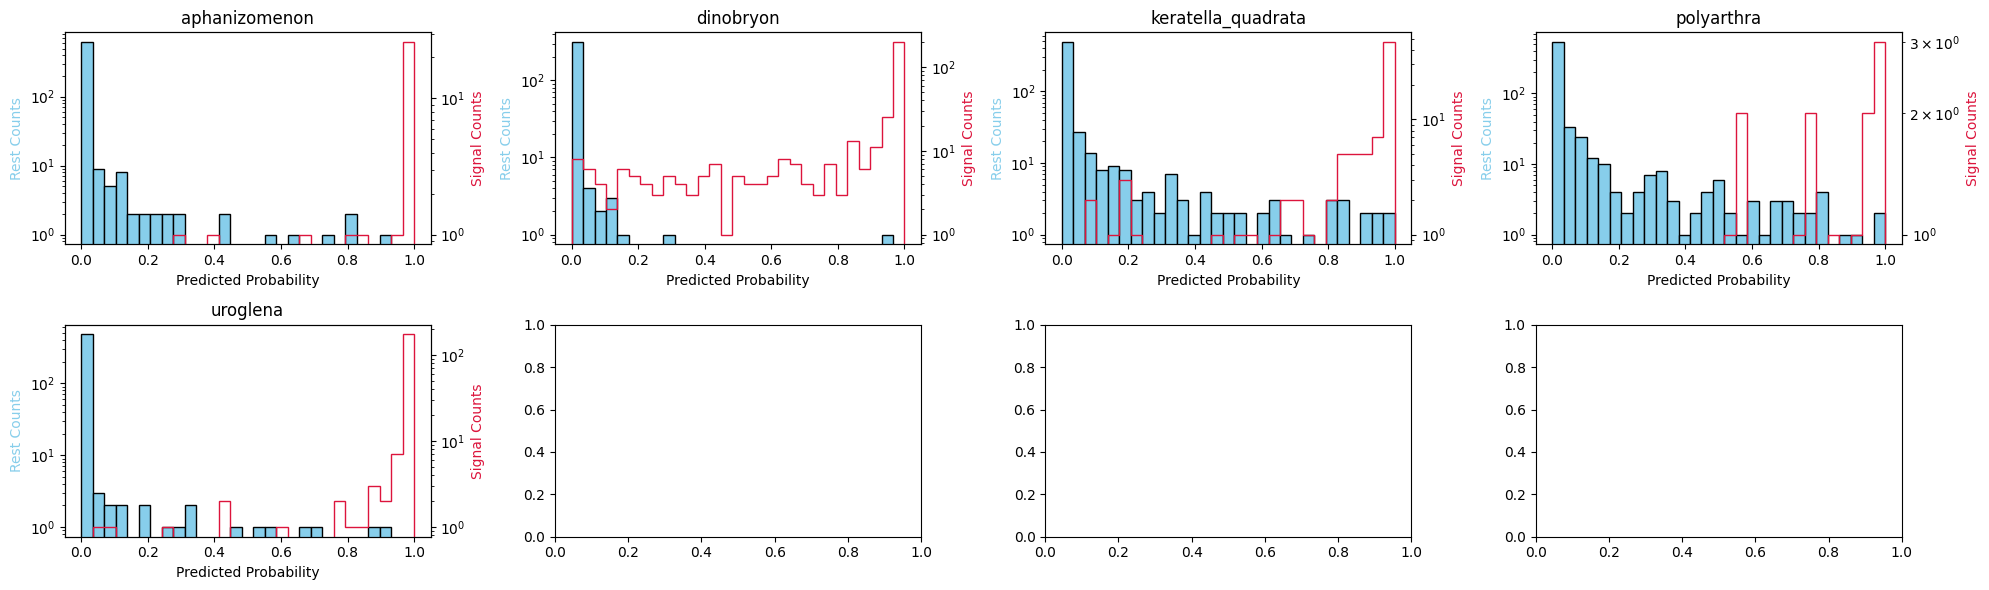

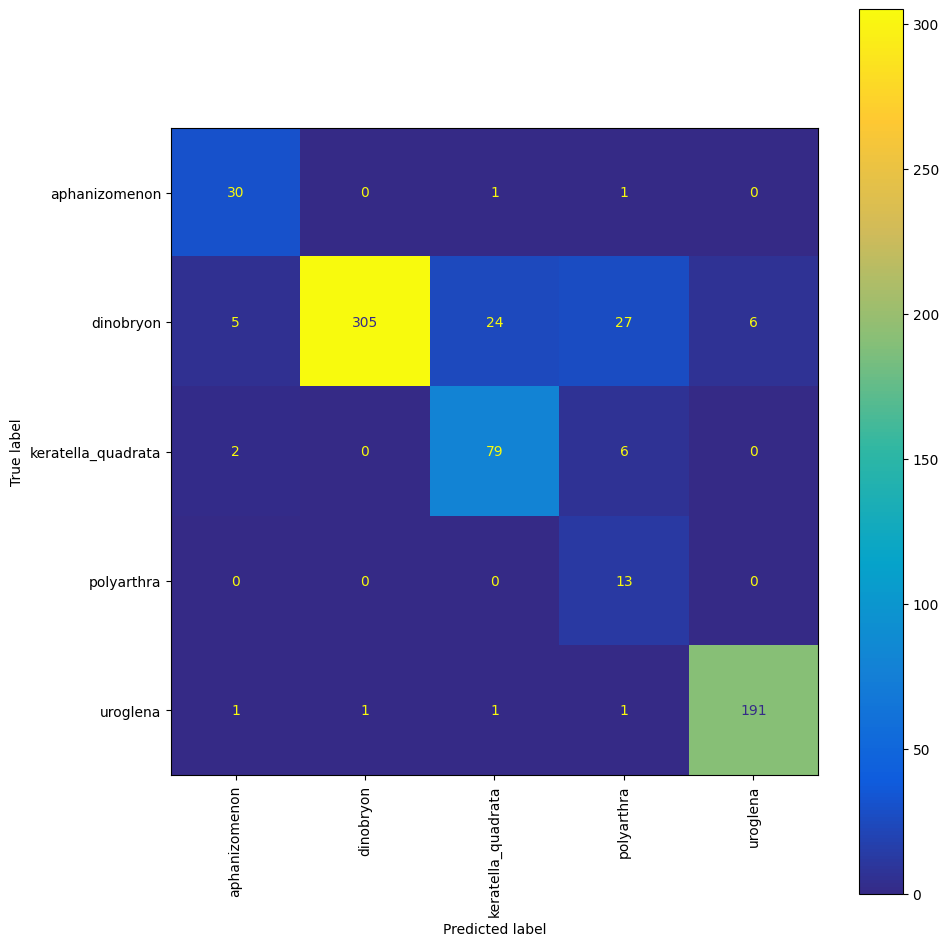

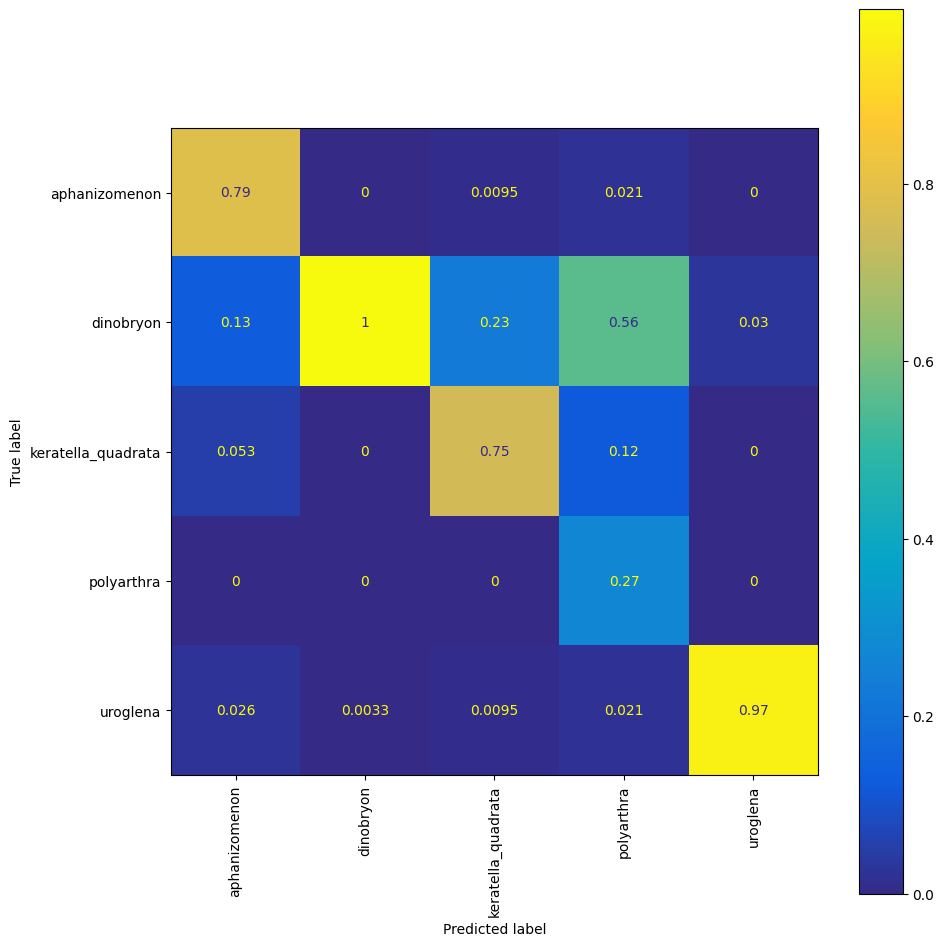

INFO: `Trainer.fit` stopped: `max_epochs=2` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=2` reached.


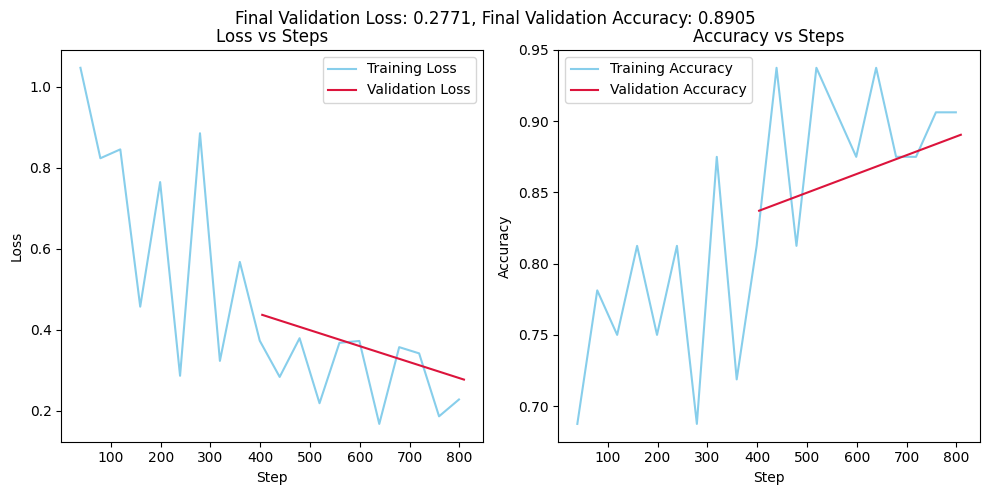

Artefatcs saved to ../train_out/csv_logs/version_43


/home/EAWAG/ruizjuan/Repos/plankton_classifier/.venv/lib/python3.9/site-packages/lightning/fabric/utilities/cloud_io.py:57: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.


In [29]:
log_dir = trainer.log_dir
trainer.fit(model, datamodule=datamodule)

In [30]:

trainer.validate(model, datamodule=datamodule)

INFO: Initializing distributed: GLOBAL_RANK: 0, MEMBER: 1/1
INFO:lightning.fabric.utilities.distributed:Initializing distributed: GLOBAL_RANK: 0, MEMBER: 1/1
INFO: ----------------------------------------------------------------------------------------------------
distributed_backend=nccl
All distributed processes registered. Starting with 1 processes
----------------------------------------------------------------------------------------------------

INFO:lightning.pytorch.utilities.rank_zero:----------------------------------------------------------------------------------------------------
distributed_backend=nccl
All distributed processes registered. Starting with 1 processes
----------------------------------------------------------------------------------------------------

/home/EAWAG/ruizjuan/Repos/plankton_classifier/.venv/lib/python3.9/site-packages/lightning/fabric/loggers/csv_logs.py:268: Experiment logs directory ../train_out/csv_logs/version_43 exists and is not empty. Pr

size 224
size 224


INFO:lit_ecology_classifier.data.datamodule:Setting up the dataset based on the provided split overview.
INFO:lit_ecology_classifier.data.datamodule:Train size of df: 12980
INFO:lit_ecology_classifier.data.datamodule:Validation size of df: 694
INFO:lit_ecology_classifier.data.datamodule:Test size of df: 695


Train size of df:  12980
Validation size of df:  694
Test size of df:  695


INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


Validation: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
     Validate metric           DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
         val_acc             0.890489935874939
    val_balanced_acc        0.9312191605567932
         val_f1             0.9382429122924805
        val_loss            0.27711260318756104
      val_precision         0.9969512224197388
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


[{'val_loss': 0.27711260318756104,
  'val_acc': 0.890489935874939,
  'val_f1': 0.9382429122924805,
  'val_balanced_acc': 0.9312191605567932,
  'val_precision': 0.9969512224197388}]

# Testing


## Option 1: test the model you just trained

In [31]:
output_path = base_path / "output_test" # Output directory for all tests

In [32]:
model.hparams.test_outpath = output_path 
model.hparams.model_name="test_model_1" # Identifier for this specific test
trainer.test(model, datamodule=datamodule)

INFO: Initializing distributed: GLOBAL_RANK: 0, MEMBER: 1/1
INFO:lightning.fabric.utilities.distributed:Initializing distributed: GLOBAL_RANK: 0, MEMBER: 1/1
INFO: ----------------------------------------------------------------------------------------------------
distributed_backend=nccl
All distributed processes registered. Starting with 1 processes
----------------------------------------------------------------------------------------------------

INFO:lightning.pytorch.utilities.rank_zero:----------------------------------------------------------------------------------------------------
distributed_backend=nccl
All distributed processes registered. Starting with 1 processes
----------------------------------------------------------------------------------------------------

/home/EAWAG/ruizjuan/Repos/plankton_classifier/.venv/lib/python3.9/site-packages/lightning/fabric/loggers/csv_logs.py:268: Experiment logs directory ../train_out/csv_logs/version_43 exists and is not empty. Pr

size 224
size 224


INFO:lit_ecology_classifier.data.datamodule:Setting up the dataset based on the provided split overview.
INFO:lit_ecology_classifier.data.datamodule:Train size of df: 12980
INFO:lit_ecology_classifier.data.datamodule:Validation size of df: 694
INFO:lit_ecology_classifier.data.datamodule:Test size of df: 695


Train size of df:  12980
Validation size of df:  694
Test size of df:  695


INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


Testing: |          | 0/? [00:00<?, ?it/s]

test_roc_auc_binary: 0.9933069381598794
test_balanced_acc: 0.9073957369670682
test_false_positives: 0.09375
test_acc: 0.8964028776978418
test_f1: 0.7937018534530105
test_auc_macro: 0.9895771129571571
test_precision: 0.7564012190587086
test_recall: 0.9073957369670682


[{}]

## Option 2: load a model you trained, and test it

In [33]:
# path for the classification path - these lines are commented out because you should have already loaded them
# train_out = base_path / "train_out"
# logger = CSVLogger(save_dir= train_out, name='csv_logs')


output_path.mkdir(parents=True, exist_ok=True)
load_model_path = Path(log_dir) / "checkpoints" / "last.ckpt"
print(load_model_path)
print('Model exists:',load_model_path.exists())

../train_out/csv_logs/version_43/checkpoints/last.ckpt
Model exists: True


In [34]:
model = LitClassifier.load_from_checkpoint(load_model_path)

INFO:timm.models._builder:Loading pretrained weights from Hugging Face hub (timm/tf_mobilenetv3_small_075.in1k)
INFO:timm.models._hub:[timm/tf_mobilenetv3_small_075.in1k] Safe alternative available for 'pytorch_model.bin' (as 'model.safetensors'). Loading weights using safetensors.
INFO:root:Model initialized with hyperparameters:
 {'TTA': False,
 'architecture': 'mobilenetv3s',
 'batch_size': 32,
 'class_map': {'aphanizomenon': 0,
               'dinobryon': 1,
               'keratella_quadrata': 2,
               'polyarthra': 3,
               'uroglena': 4},
 'datapath': '../data/mini_dataset',
 'finetune': False,
 'loss': 'cross_entropy',
 'lr': 0.0001,
 'main_param_path': PosixPath('../params'),
 'model_name': 'mobilenetv3s_2025-03-10_12-40-19',
 'no_use_multi': False,
 'num_classes': 5,
 'splits':                                                    image               class  \
0      SPC-EAWAG-0P5X-1657469153953175-61976020245260...  keratella_quadrata   
1      SPC-EAWAG-0P5X-1

Model setup completed.
Model architecture:  mobilenetv3s
Number of classes:  5
Pretrained:  True
Total number of trainable parameters: %d 1021997
Total number of parameters: %d 1021997
Using standard cross entropy loss


In [35]:
model.hparams.test_outpath = output_path
model.hparams.model_name="test_model_1"
model.hparams.dataset="mini_dataset"
model.hparams.splits=my_split
model.hparams.datamodule = "fix"
model.load_datamodule(datamodule)

In [36]:
trainer = pl.Trainer(
        # Set the number of GPUs to use for prediction if no_gpu is not set
        devices=  1, 
        strategy= "auto",
        enable_progress_bar = True,
        default_root_dir=output_path,
        logger=logger,
    )
    

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: IPU available: False, using: 0 IPUs
INFO:lightning.pytorch.utilities.rank_zero:IPU available: False, using: 0 IPUs
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs


/home/EAWAG/ruizjuan/Repos/plankton_classifier/.venv/lib/python3.9/site-packages/lightning/fabric/loggers/csv_logs.py:268: Experiment logs directory ../train_out/csv_logs/version_43 exists and is not empty. Previous log files in this directory will be deleted when the new ones are saved!
INFO:lit_ecology_classifier.data.datamodule:Setting up the dataset based on the provided split overview.
INFO:lit_ecology_classifier.data.datamodule:Train size of df: 12980
INFO:lit_ecology_classifier.data.datamodule:Validation size of df: 694
INFO:lit_ecology_classifier.data.datamodule:Test size of df: 695
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


size 224
size 224
Train size of df:  12980
Validation size of df:  694
Test size of df:  695


Testing: |          | 0/? [00:00<?, ?it/s]

test_roc_auc_binary: 0.9933069381598794
test_balanced_acc: 0.9073957369670682
test_false_positives: 0.09375
test_acc: 0.8964028776978418
test_f1: 0.7937018534530105
test_auc_macro: 0.9895771129571571
test_precision: 0.7564012190587086
test_recall: 0.9073957369670682


[{}]

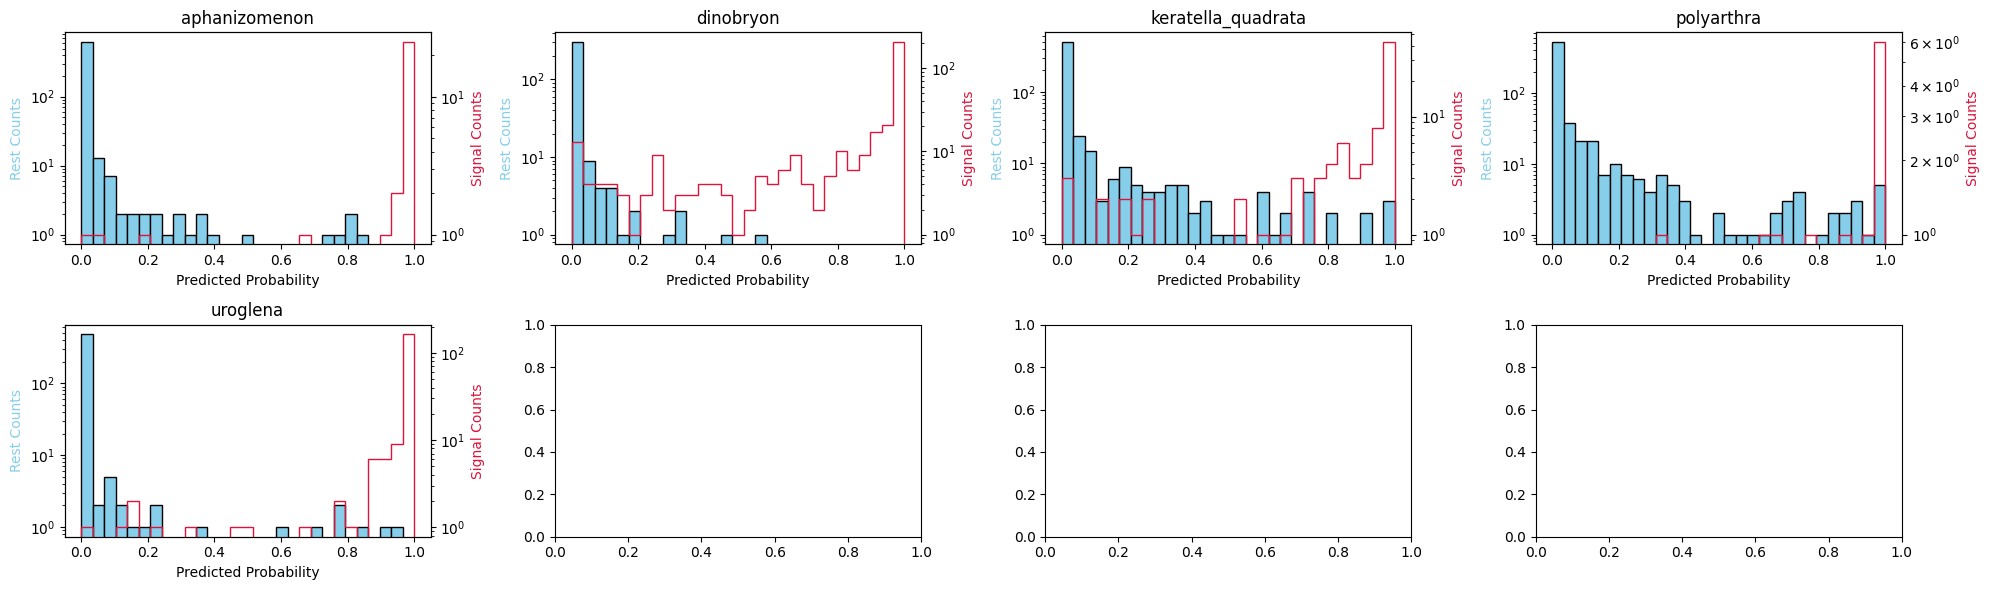

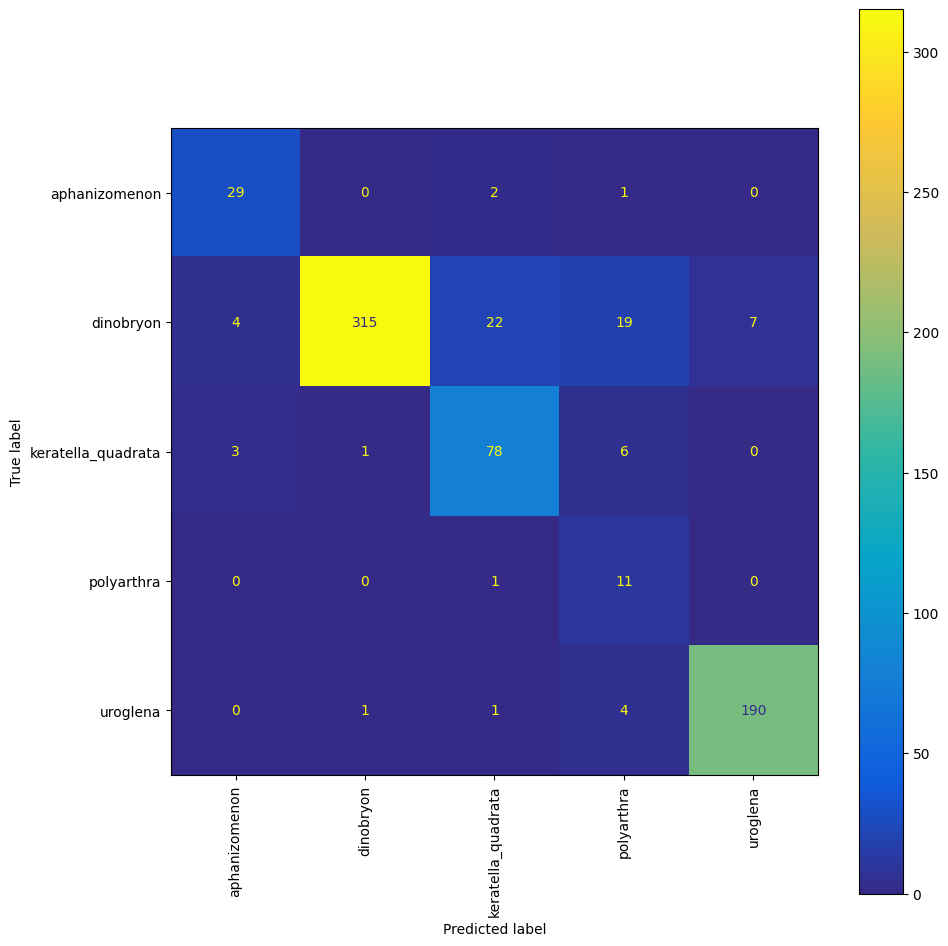

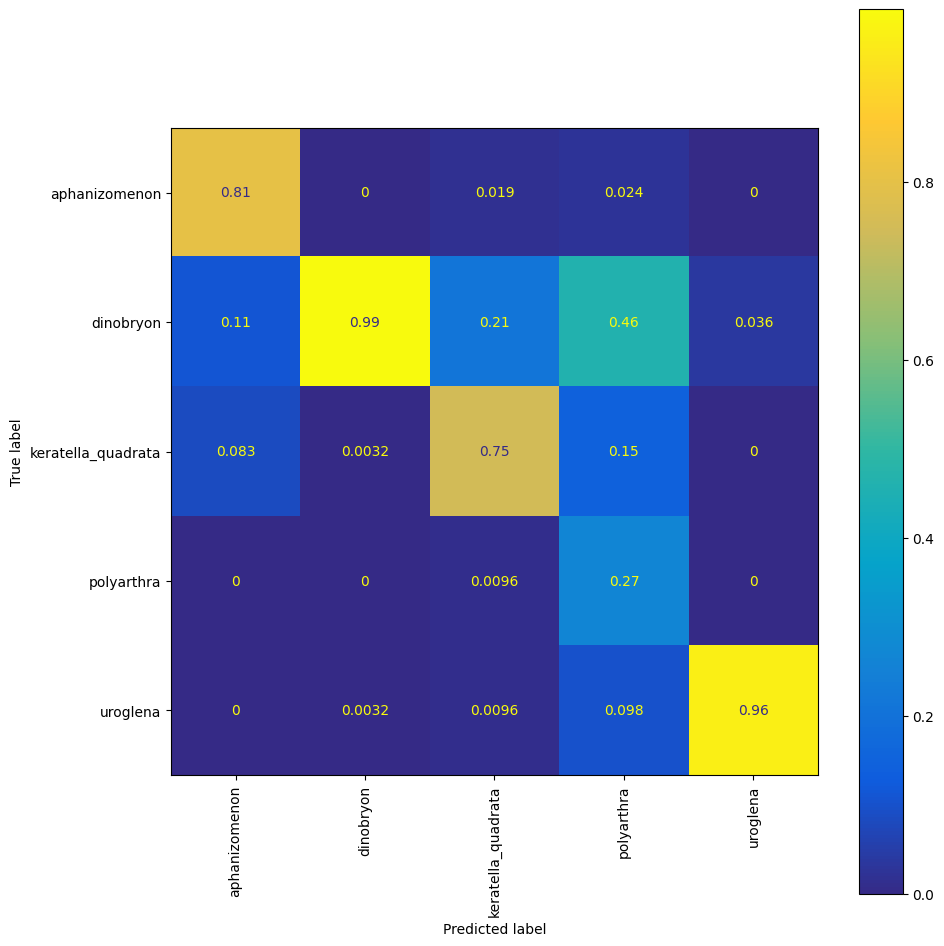

In [37]:
trainer.test(model, datamodule=datamodule)

# OOD Testing of your model

In [38]:
dataOOD_path = base_path / "data" /"mini_OOD"/"OOD1"


In [39]:
datamoduleOOD = DataModule(
    datapath=dataOOD_path,
    dataset="OOD1",
    batch_size=128,
    splits=None,
    augmentation_level="low",
    resize_with_proportions=True,
    target_size=224,
    only_test=True)
 
datamoduleOOD.setup("test")
model.load_datamodule(datamoduleOOD)



INFO:root: Extracting class map from tar file.
INFO:lit_ecology_classifier.helpers.helpers:Extracting class map.
INFO:lit_ecology_classifier.helpers.helpers:Detected directory.
INFO:lit_ecology_classifier.helpers.helpers:Found 4 classes.
INFO:root:Class map: {'aphanizomenon': 0, 'dinobryon': 1, 'keratella_quadrata': 2, 'uroglena': 3}
INFO:lit_ecology_classifier.data.datamodule:Setting up the test dataset only.
INFO:lit_ecology_classifier.data.datamodule:Test size: 709


Setting up the test dataset only.
size 224
size 224


In [40]:
trainerOOD = pl.Trainer(
        devices=  1,
        strategy= "auto",
        enable_progress_bar = True,
        default_root_dir=output_path,
        logger=logger,
    )


INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: IPU available: False, using: 0 IPUs
INFO:lightning.pytorch.utilities.rank_zero:IPU available: False, using: 0 IPUs
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs


INFO:lit_ecology_classifier.data.datamodule:Setting up the test dataset only.
INFO:lit_ecology_classifier.data.datamodule:Test size: 709
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


Setting up the test dataset only.
size 224
size 224


Testing: |          | 0/? [00:00<?, ?it/s]

/home/EAWAG/ruizjuan/Repos/plankton_classifier/notebooks/lit_ecology_classifier/helpers/modelling_plots.py:127: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  y_axis.set_yscale("log")
/home/EAWAG/ruizjuan/Repos/plankton_classifier/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:2480: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/home/EAWAG/ruizjuan/Repos/plankton_classifier/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:2642: UserWarning: labels size, 4, does not match size of target_names, 5
  warnings.warn(


test_roc_auc_binary: 1.0
test_balanced_acc: 0.6305142384947877
test_false_positives: 0.0
test_acc: 0.8617771509167842
test_f1: 0.39549558262253015
test_auc_macro: 0.9087315456450771
test_precision: 0.355225988700565
test_recall: 0.6305142384947877


[{}]

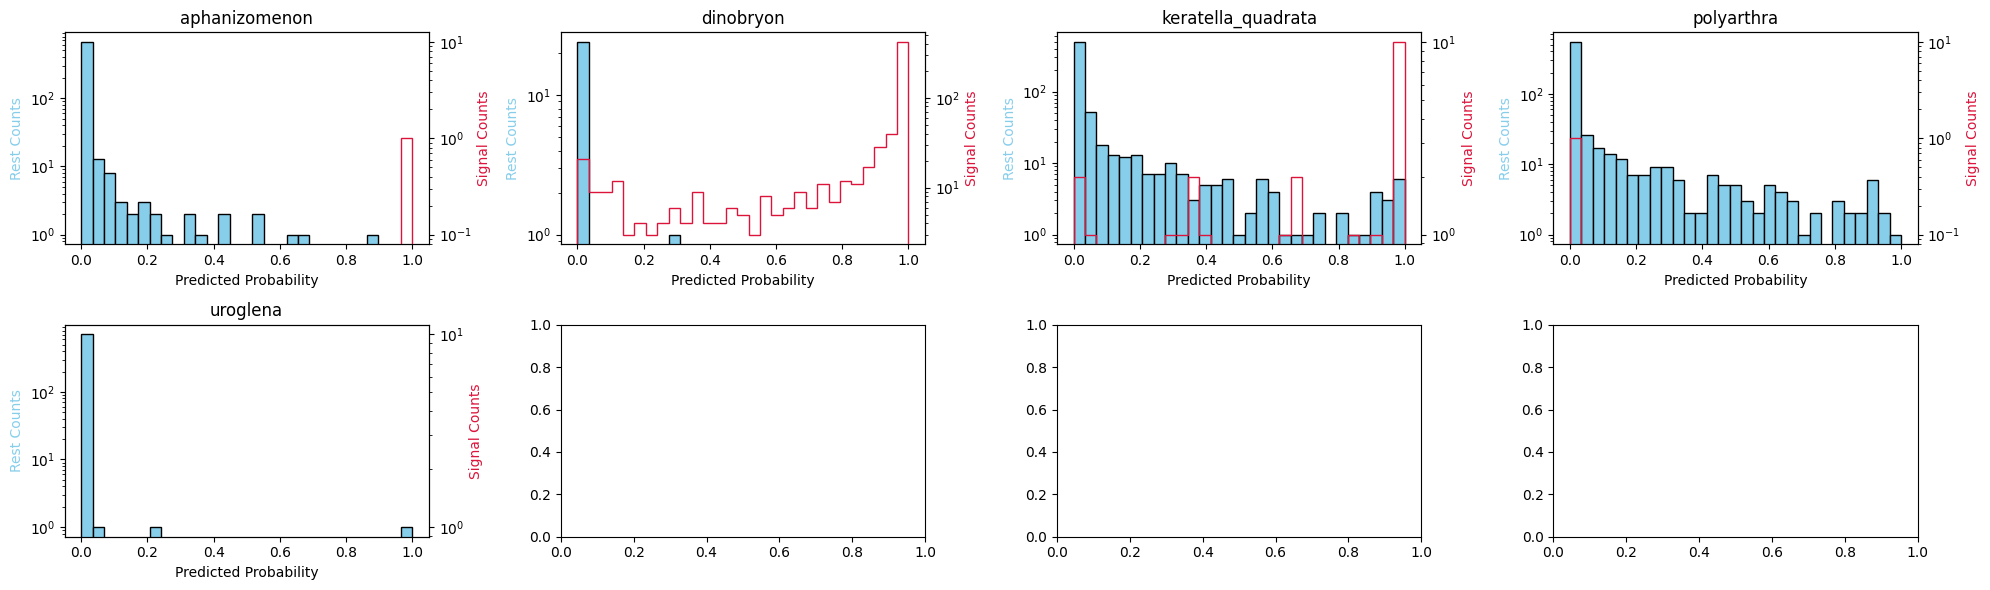

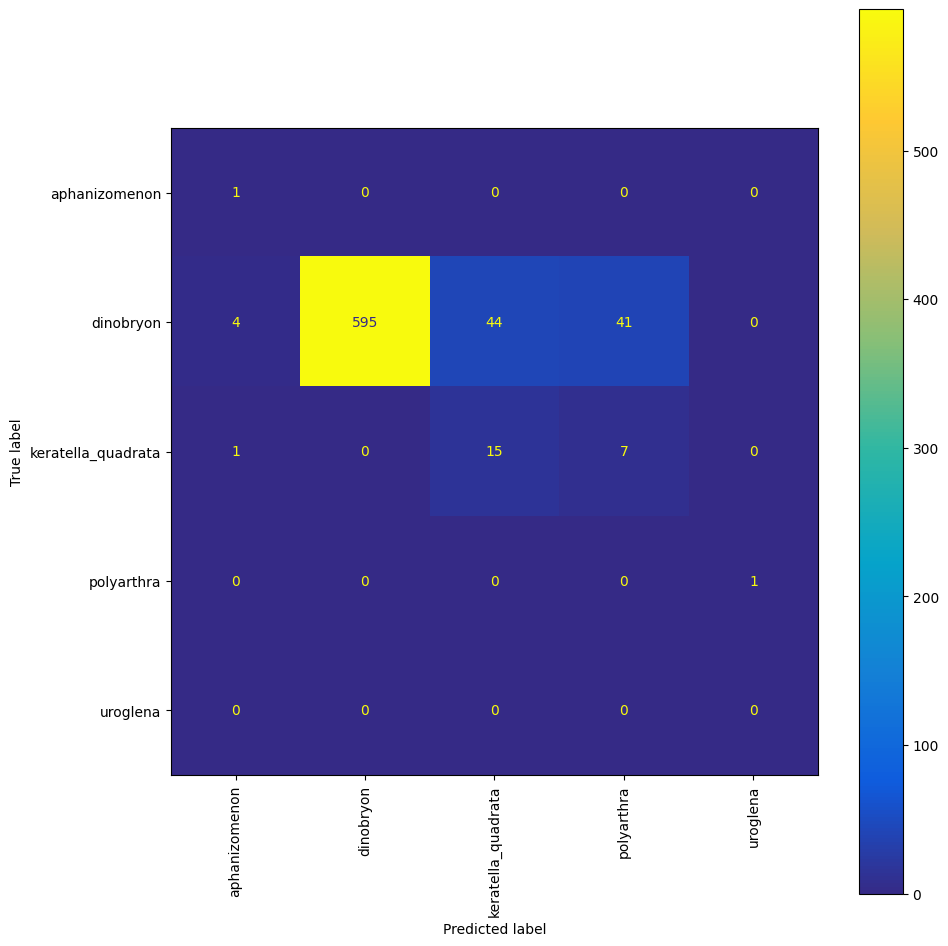

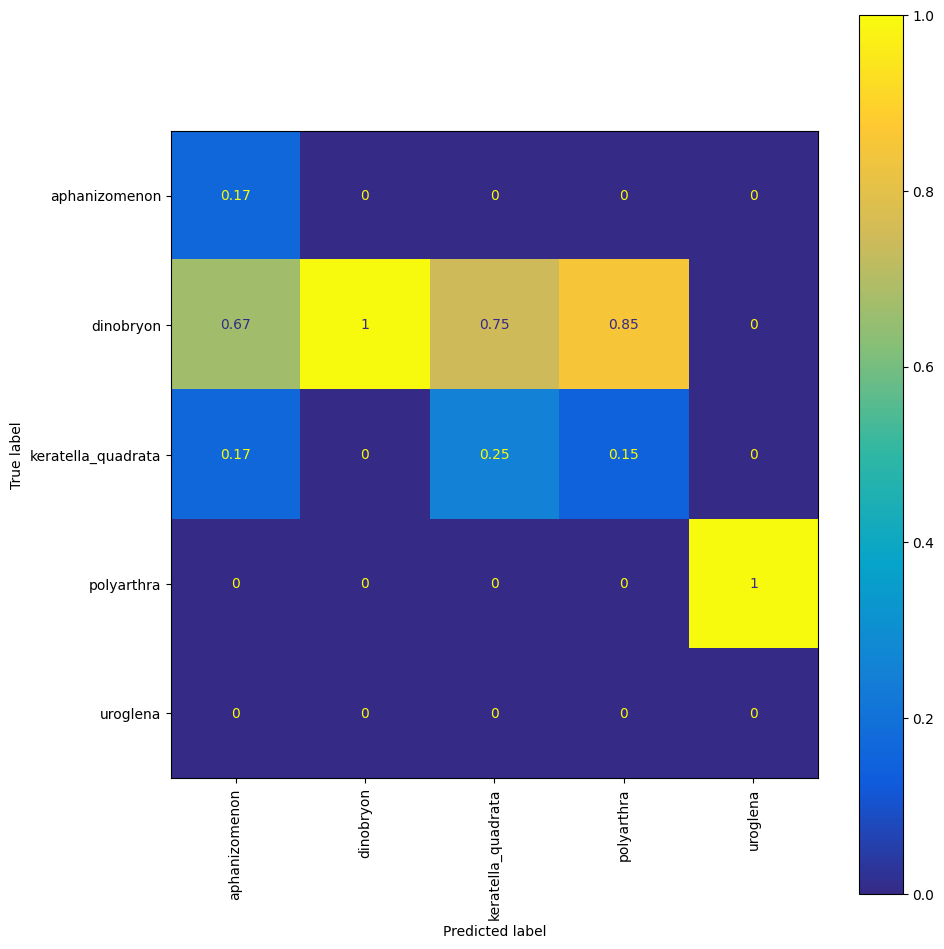

In [41]:
trainerOOD.test(model, datamodule=datamoduleOOD)

In [42]:
test_acc = model.test_acc
test_f1 = model.test_f1
model_name = model.hparams.model_name
test_cells = model.test_cell 

print(f"Test accuracy for {model_name} is {test_acc:.2f}")
print(f"Test F1 for {model_name} is {test_f1:.2f}")


Test accuracy for test_model_1 is 0.86
Test F1 for test_model_1 is 0.40


In [43]:
raise Exception("For the following, you need to have downloaded an model")

Exception: For the following, you need to have downloaded an model

# Load a model we trained earlier, and test it

This model, which is 1Gb heavy, can be downloaded from

[https://www.dropbox.com/scl/fi/7sx76tfha4duyvhs8amq4/zoo3.ckpt?rlkey=hmlyzgq3yovt8gjyhadwic3vw&st=zjlqtb7v&dl=1](https://www.dropbox.com/scl/fi/7sx76tfha4duyvhs8amq4/zoo3.ckpt?rlkey=hmlyzgq3yovt8gjyhadwic3vw&st=zjlqtb7v&dl=1
)

The paths in the following cell need to reflect the directory where you downloaded the file.

In [ ]:
# path for the classification path
output_path = base_path / "output_test" 

output_path.mkdir(parents=True, exist_ok=True)
model_path = base_path / ".." / "models" / "benno"/ "zoo3.ckpt"

print('Model can be found:',model_path.exists())

In [ ]:
train_out = base_path / "train_out"
logger = CSVLogger(save_dir= train_out, name='csv_logs')

model = LitClassifier.load_from_checkpoint(model_path, strict=False)
loaded_class_map = model.class_map

In [ ]:
# model.hparams.batch_size = 128
# model.hparams.TTA = False
model.hparams.test_outpath = str(output_path)
model.hparams.datapath = str(dataset_path)
model.hparams.use_wandb = False
model.hparams.model_name = "zoo3"
model.hparams.only_test = True
model.hparams.splits=my_split




In [ ]:
for my_class in model.hparams.splits['class'].unique():
    model.hparams.splits['class_map'].loc[model.hparams.splits['class'] == my_class] = loaded_class_map[my_class]

In [ ]:
print(model.hparams)

In [ ]:
data_module = DataModule(**model.hparams)
data_module.setup("test")
model.load_datamodule(data_module)

In [ ]:
trainer = pl.Trainer(
        # Set the number of GPUs to use for prediction if no_gpu is not set
        devices=  1, 
        strategy= "auto",
        enable_progress_bar = True,
        default_root_dir=output_path,
        logger=logger,
    )

In [ ]:
trainer.test(model, datamodule=data_module)

Note that both keratella and polyarthra are rotifers

In [ ]:
test_acc = model.test_acc
test_f1 = model.test_f1
model_name = model.hparams.model_name
test_cells = model.test_cell 

print(f"Test accuracy for {model_name} is {test_acc:.2f}")
print(f"Test F1 for {model_name} is {test_f1:.2f}")


# OOD Testing

## Test on a single OOD cell

In [ ]:
dataOOD_path = base_path / "data" /"mini_OOD"/"OOD1"

In [ ]:
modelOOD = LitClassifier.load_from_checkpoint(model_path, strict=False)

In [ ]:
modelOOD.hparams.batch_size = 128
modelOOD.hparams.TTA = False
modelOOD.hparams.test_outpath = str(output_path)
modelOOD.hparams.datapath = str(dataOOD_path)
modelOOD.hparams.use_wandb = False
modelOOD.hparams.model_name = "zoo3"
modelOOD.hparams.only_test = True


In [ ]:
data_module = DataModule(**modelOOD.hparams)
data_module.setup("test")
modelOOD.load_datamodule(data_module)

In [ ]:
trainerOOD = pl.Trainer(
        # Set the number of GPUs to use for prediction if no_gpu is not set
        devices=  1, 
        strategy= "auto",
        enable_progress_bar = True,
        default_root_dir=output_path,
        logger=logger,
    )

In [ ]:
trainerOOD.test(modelOOD, datamodule=data_module)

In [ ]:
test_acc = modelOOD.test_acc
test_f1 = modelOOD.test_f1
model_name = modelOOD.hparams.model_name
test_cells = modelOOD.test_cell 

print(f"Test accuracy for {model_name} is {test_acc:.2f}")
print(f"Test F1 for {model_name} is {test_f1:.2f}")


## Test on a multiple OOD cells

In [ ]:
#model
model_paths = [model_path]

#model containing the model to be tested
ood_dir = "..//data//mini_OOD"

# alternatively, you can give multiple 
test_cells = ["..//data//mini_OOD//OOD1", "..//data//mini_OOD//OOD2",]


In [ ]:
from lit_ecology_classifier.test_cells import Testing
import torch

cell_tester = Testing(model_paths, output_path, ood_dir=ood_dir, strict=False)

trainer = pl.Trainer(
        devices=1,
        strategy="auto",
        enable_progress_bar=True, default_root_dir=output_path
        )
    
cell_tester.trainer(trainer)
cell_tester.test()


In [ ]:
performance_df = cell_tester.get_performance_overview()
performance_df

In [ ]:
from lit_ecology_classifier.helpers.modelling_plots import plot_model_performance

plot_model_performance(performance_df)
